# EfficientNetV2 Baseline

## Objective

This notebook establishes the first image-classification baseline for the
brain tumor MRI dataset using EfficientNetV2.

The experiment uses the fixed train, validation, and test partitions generated
in `02_data_preparation.ipynb`. No dataset splitting or case-group
reconstruction is performed in this notebook.

The objectives are to:

- build a reproducible image-loading pipeline from the frozen classification
  manifest;
- apply training-only data augmentation appropriate for brain MRI images;
- train an EfficientNetV2 baseline using transfer learning;
- evaluate performance beyond overall accuracy using class-specific metrics;
- analyze performance across pathology classes and MRI modalities;
- establish a reference baseline for subsequent architecture comparisons.

The test partition will remain untouched during model development and will be
used only for final evaluation.

## 1. Setup and experiment configuration

In [28]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
IN_COLAB = (
    "COLAB_GPU" in os.environ
    or "COLAB_RELEASE_TAG" in os.environ
)

if IN_COLAB:
    PROJECT_ROOT = Path("/content/brain-tumor-mri")
else:
    PROJECT_ROOT = Path.cwd().parent

MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "classification_manifest.csv"
)

RANDOM_STATE = 42


Running in Colab: False
Project root: /home/swsq2526/brain-tumor-mri
Manifest: /home/swsq2526/brain-tumor-mri/data/processed/classification_manifest.csv
Exists: True


In [30]:
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPUs: []


In [3]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Shape:", manifest.shape)
print()
print(manifest["split"].value_counts())

manifest.head()

Shape: (11300, 12)

split
train         7928
validation    1699
test          1673
Name: count, dtype: int64


,relative_path,resolved_relative_path,pathology,modality,split_group,split,width,height,point,location,description,pixel_hash
0,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,data/raw/Astrocytoma T1C+/T1C+ - Diffuse astro...,Astrocytoma,T1C+,9,test,512,512,"{'x': 328, 'y': 150}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",4426b6ab1d355bb7007e793bea34c592437118bff6d766...
1,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,data/raw/Astrocytoma T1C+/T1C+ - Diffuse astro...,Astrocytoma,T1C+,9,test,512,512,"{'x': 324, 'y': 148}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",bb287c29aa575b46674ccf89141a3a9d0608af47f80bed...
2,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,data/raw/Astrocytoma T1C+/T1C+ - Diffuse astro...,Astrocytoma,T1C+,9,test,512,512,"{'x': 328, 'y': 142}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",22b7ecd552e34cd825f1a378e6f44fdb6ece3f8301a52c...
3,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,data/raw/Astrocytoma T1C+/T1C+ - Diffuse astro...,Astrocytoma,T1C+,9,test,512,512,"{'x': 347, 'y': 148}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",d13368e89e8179f39bd06fd5edbabafb3b9e6a4974e0a9...
4,Astrocytoma T1\T1 - Diffuse astrocytoma fronta...,data/raw/Astrocytoma T1/T1 - Diffuse astrocyto...,Astrocytoma,T1,9,test,512,512,"{'x': 318, 'y': 153}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",442dd55ce6e3f167adcf58c8156ebb5045ec12c6d471bb...


In [4]:
train_df = manifest[manifest["split"] == "train"].copy()
val_df = manifest[manifest["split"] == "validation"].copy()
test_df = manifest[manifest["split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7928
Validation: 1699
Test: 1673


In [5]:
assert len(train_df) == 7928
assert len(val_df) == 1699
assert len(test_df) == 1673

assert set(train_df["split_group"]).isdisjoint(val_df["split_group"])
assert set(train_df["split_group"]).isdisjoint(test_df["split_group"])
assert set(val_df["split_group"]).isdisjoint(test_df["split_group"])

print("✓ Frozen manifest loaded successfully.")
print("✓ Expected train/validation/test sizes recovered.")
print("✓ No split_group crosses model partitions.")

✓ Frozen manifest loaded successfully.
✓ Expected train/validation/test sizes recovered.
✓ No split_group crosses model partitions.


## 2. Model framework and input pipeline

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = train_df["pathology"].nunique()

CLASS_NAMES = sorted(train_df["pathology"].unique())

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", NUM_CLASSES)
print(CLASS_NAMES)

Image size: 224
Batch size: 32
Classes: 10
['Astrocytoma', 'Ependymoma', 'Glioma', 'Hemangiopericytoma', 'Meningioma', 'Neurocytoma', 'Normal', 'Oligodendroglioma', 'Other', 'Schwannoma']


In [9]:
class_to_index = {
    class_name: idx
    for idx, class_name in enumerate(CLASS_NAMES)
}

index_to_class = {
    idx: class_name
    for class_name, idx in class_to_index.items()
}

train_df["label"] = train_df["pathology"].map(class_to_index)
val_df["label"] = val_df["pathology"].map(class_to_index)
test_df["label"] = test_df["pathology"].map(class_to_index)

train_df[["pathology", "label"]].drop_duplicates().sort_values("label")

,pathology,label
1673,Astrocytoma,0
2455,Ependymoma,1
3180,Glioma,2
4214,Hemangiopericytoma,3
4642,Meningioma,4
6091,Neurocytoma,5
6527,Normal,6
7277,Oligodendroglioma,7
7662,Other,8
8735,Schwannoma,9


In [10]:
for subset in [train_df, val_df, test_df]:
    subset["image_path"] = subset["resolved_relative_path"].apply(
        lambda p: str(PROJECT_ROOT / p)
    )

In [11]:
assert train_df["image_path"].apply(lambda p: Path(p).exists()).all()
assert val_df["image_path"].apply(lambda p: Path(p).exists()).all()
assert test_df["image_path"].apply(lambda p: Path(p).exists()).all()

print("✓ All model input paths exist.")

✓ All model input paths exist.


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    image = tf.cast(image, tf.float32)

    return image, label

In [13]:
def make_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["image_path"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [16]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print(
    "Pixel range:",
    float(tf.reduce_min(images)),
    float(tf.reduce_max(images))
)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image dtype: <dtype: 'float32'>
Pixel range: 0.0 255.0


## 3. Training data augmentation

Data augmentation is applied only during training.

Because the dataset contains brain MRI images, augmentation is intentionally
conservative. The objective is to improve robustness to small acquisition and
positioning variations without substantially altering anatomical structure.

The baseline uses:

- small rotations;
- small translations;
- mild zoom variations.

Vertical flipping is excluded because it would produce anatomically implausible
orientations. Horizontal flipping is also excluded from the baseline to avoid
introducing unnecessary left-right anatomical transformations.

Validation and test images are never augmented.

In [ ]:

data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(
            factor=0.03,
            fill_mode="reflect"
        ),
        layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="reflect"
        ),
        layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            fill_mode="reflect"
        ),
    ],
    name="data_augmentation"
)

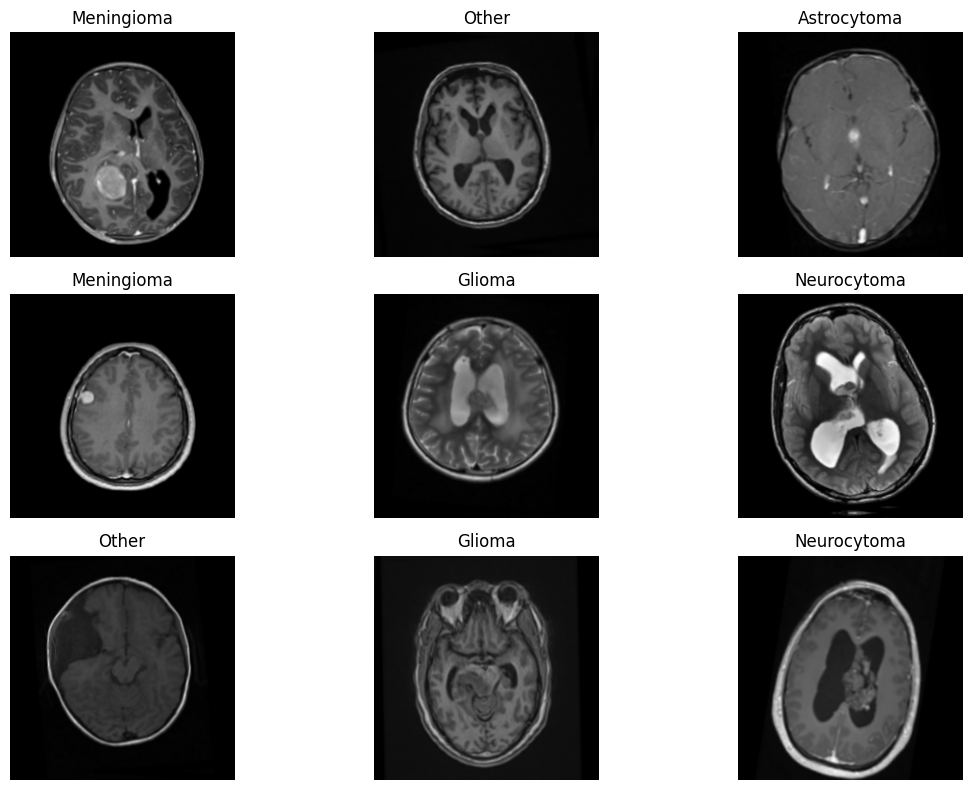

In [18]:
sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(9):
    augmented_image = data_augmentation(
        sample_images[i:i+1],
        training=True
    )[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(
        tf.cast(
            tf.clip_by_value(augmented_image, 0, 255),
            tf.uint8
        )
    )
    plt.title(
        index_to_class[int(sample_labels[i])]
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Augmentation validation

Visual inspection confirmed that the selected training augmentations preserve
the overall anatomical structure of the MRI images.

Small rotations, translations, and zoom variations introduce moderate spatial
variability without substantially distorting brain anatomy or removing visible
lesion regions from the field of view.

This conservative augmentation strategy is therefore retained for the
EfficientNetV2 baseline.


## 4. EfficientNetV2B0 transfer-learning baseline

The first classification model uses EfficientNetV2B0 pretrained on ImageNet.

During the initial training stage, the pretrained convolutional backbone is
frozen and only a newly initialized classification head is trained.

This provides a transfer-learning baseline before evaluating whether
fine-tuning part of the pretrained backbone improves performance.

In [19]:
base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=True,
)

base_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


In [20]:
inputs = keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="image"
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.3,
    name="dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="efficientnetv2b0_baseline"
)

In [21]:
model.summary()

Model: "efficientnetv2b0_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [22]:
print(
    "Total parameters:",
    f"{model.count_params():,}"
)

print(
    "Trainable parameters:",
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

print(
    "Non-trainable parameters:",
    f"{sum(np.prod(v.shape) for v in model.non_trainable_weights):,}"
)

Total parameters: 5,932,122
Trainable parameters: 12,810
Non-trainable parameters: 5,919,312


In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [24]:
CHECKPOINT_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_MODEL_PATH = (
    CHECKPOINT_DIR / "efficientnetv2b0_baseline.keras"
)

In [25]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=BASELINE_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [26]:
smoke_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1
)

248/248 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.3850 - loss: 1.7611 - val_accuracy: 0.3078 - val_loss: 2.0212
